In [124]:
"""
mcPHASES — Script 3: Modeling Pipeline
========================================
Targets:
  - stress_score
  - rmssd (HRV proxy)
  - overall_score (sleep score)

Pipeline:
  0. Load & merge master DataFrame
  1. Participant-level 30/6/6 split
  2. Feature engineering (phase interactions, within-person centering)
  3. Feature reduction
       a. Correlation filtering
       b. Lasso/ElasticNet selection
       c. PCA (parallel, for comparison)
  4. Model training per target
       - Ridge (baseline)
       - Lasso
       - Random Forest
       - XGBoost
       - LightGBM
       - Linear Mixed Effects (statsmodels)
  5. Validation tuning & model selection
  6. Test set evaluation
  7. SHAP feature importance
  8. Phase-stratified performance breakdown
  9. Summary report
"""

'\nmcPHASES — Script 3: Modeling Pipeline\n========================================\nTargets:\n  - stress_score\n  - rmssd (HRV proxy)\n  - overall_score (sleep score)\n\nPipeline:\n  0. Load & merge master DataFrame\n  1. Participant-level 30/6/6 split\n  2. Feature engineering (phase interactions, within-person centering)\n  3. Feature reduction\n       a. Correlation filtering\n       b. Lasso/ElasticNet selection\n       c. PCA (parallel, for comparison)\n  4. Model training per target\n       - Ridge (baseline)\n       - Lasso\n       - Random Forest\n       - XGBoost\n       - LightGBM\n       - Linear Mixed Effects (statsmodels)\n  5. Validation tuning & model selection\n  6. Test set evaluation\n  7. SHAP feature importance\n  8. Phase-stratified performance breakdown\n  9. Summary report\n'

In [125]:
%pip install shap
%pip install xgboost
%pip install lightgbm
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [126]:
# ─────────────────────────────────────────────
# 0. IMPORTS & CONFIG
# ─────────────────────────────────────────────
import os, warnings, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

In [127]:
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.compose           import ColumnTransformer
from sklearn.impute             import SimpleImputer
from sklearn.decomposition     import PCA
from sklearn.linear_model      import Ridge, Lasso, ElasticNet
from sklearn.ensemble          import RandomForestRegressor
from sklearn.metrics           import (mean_absolute_error,
                                        mean_squared_error, r2_score)
from sklearn.inspection        import permutation_importance
from xgboost                   import XGBRegressor
from lightgbm                  import LGBMRegressor
import statsmodels.formula.api as smf

In [128]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

In [129]:
DATA_DIR = "./data"
OUT_DIR  = "./eda_outputs/script3_modeling"
os.makedirs(OUT_DIR, exist_ok=True)

In [130]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [131]:
PHASE_ORDER  = ["menstrual", "follicular", "fertility", "luteal"]
PHASE_COLORS = {"menstrual": "#e07b7b", "follicular": "#7bafd4",
                "fertility": "#f5c06a", "luteal":     "#a8c5da"}

In [132]:
TARGETS = {
    "stress_score" : "Fitbit Stress Score",
    "rmssd"        : "HRV (RMSSD)",
    "overall_score": "Sleep Score",
}

In [133]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight")
    plt.show()

In [134]:
def load(fname):
    return pd.read_csv(os.path.join(DATA_DIR, fname))

In [135]:
def metrics(y_true, y_pred, label=""):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = np.array(y_true)[mask], np.array(y_pred)[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"  {label:<30}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [136]:
# ─────────────────────────────────────────────
# LOAD & BUILD MASTER DATAFRAME
# (same join logic as script 1, compacted)
# ─────────────────────────────────────────────
print("Loading & merging tables …")

Loading & merging tables …


In [137]:
JOIN_KEYS = ["id", "day_in_study", "study_interval"]

In [138]:
def daily_agg(df, agg_dict):
    cols = JOIN_KEYS + list(agg_dict.keys())
    df   = df[[c for c in cols if c in df.columns]].copy()
    out  = df.groupby(JOIN_KEYS).agg(agg_dict).reset_index()
    out.columns = ["_".join(c).strip("_") if isinstance(c, tuple) else c
                   for c in out.columns]
    return out

In [139]:
hormones    = load("hormones_and_selfreport.csv")
stress      = load("stress_score.csv")
sleep_sc    = load("sleep_score.csv")
resting_hr  = load("resting_heart_rate.csv")
active_min  = load("active_minutes.csv")
calories    = load("calories.csv")
distance    = load("distance.csv")
steps_df    = load("steps.csv")
glucose_df  = load("glucose.csv")
hrv_df      = load("heart_rate_variability_details.csv")
wrist_temp  = load("wrist_temperature.csv")
comp_temp   = load("computed_temperature.csv")
resp_rate   = load("respiratory_rate_summary.csv")
vo2_df      = load("demographic_vo2_max.csv")
subjects    = load("subject-info.csv")
hw          = load("height_and_weight.csv")

In [140]:
# Standardise phase
hormones["phase"] = (hormones["phase"].astype(str)
                                       .str.strip().str.lower())
hormones = hormones[hormones["phase"].isin(PHASE_ORDER)]

In [141]:
# Daily aggregations
daily_stress  = stress[JOIN_KEYS + ["stress_score",
                                     "sleep_points",
                                     "responsiveness_points",
                                     "exertion_points"]].copy()

In [142]:
daily_sleep   = sleep_sc[JOIN_KEYS + ["overall_score",
                                       "deep_sleep_in_minutes",
                                       "restlessness",
                                       "composition_score",
                                       "revitalization_score",
                                       "duration_score"]].copy()

In [143]:
daily_rhr     = (resting_hr[JOIN_KEYS + ["value"]]
                 .rename(columns={"value": "resting_hr"}))

In [144]:
daily_active  = daily_agg(active_min,
                           {"sedentary": "mean", "lightly":   "mean",
                            "moderately":"mean", "very":      "mean"})

In [145]:
daily_cal     = daily_agg(calories,  {"calories": "sum"})
daily_dist    = daily_agg(distance,  {"distance": "sum"})
daily_steps   = daily_agg(steps_df,  {"steps":    "sum"})

In [146]:
daily_glucose = daily_agg(glucose_df,
                           {"glucose_value": ["mean", "std",
                                              "min",  "max"]})

In [147]:
# HRV — aggregate to daily (recorded during sleep)
daily_hrv = daily_agg(hrv_df,
                       {"rmssd":          "mean",
                        "coverage":       "mean",
                        "low_frequency":  "mean",
                        "high_frequency": "mean"})

In [148]:
daily_wtemp = daily_agg(wrist_temp,
                         {"temperature_diff_from_baseline": "mean"})

In [149]:
ct_cols = ["id", "study_interval", "sleep_start_day_in_study",
           "nightly_temperature",
           "baseline_relative_nightly_standard_deviation"]
comp_temp_d = (comp_temp[[c for c in ct_cols if c in comp_temp.columns]]
               .rename(columns={"sleep_start_day_in_study": "day_in_study"}))

In [150]:
resp_cols = JOIN_KEYS + ["full_sleep_breathing_rate",
                          "deep_sleep_breathing_rate",
                          "rem_sleep_breathing_rate",
                          "full_sleep_standard_deviation"]
resp_d = resp_rate[[c for c in resp_cols if c in resp_rate.columns]]

In [151]:
vo2_cols = JOIN_KEYS + ["demographic_vo2_max", "filtered_demographic_vo2_max"]
vo2_d    = vo2_df[[c for c in vo2_cols if c in vo2_df.columns]]

In [152]:
# Static participant info
hw_slim = hw[["id", "height_2022", "weight_2022"]].copy()
hw_slim["bmi"] = hw_slim["weight_2022"] / (hw_slim["height_2022"] / 100) ** 2

In [153]:
subj_slim = subjects[["id", "birth_year", "age_of_first_menarche"]].copy()
subj_slim["age"] = 2022 - subj_slim["birth_year"]

In [154]:
# Master join — left-join everything onto the hormone/phase table
master = (
    hormones
    .merge(daily_stress,  on=JOIN_KEYS, how="left")
    .merge(daily_sleep,   on=JOIN_KEYS, how="left")
    .merge(daily_rhr,     on=JOIN_KEYS, how="left")
    .merge(daily_active,  on=JOIN_KEYS, how="left")
    .merge(daily_cal,     on=JOIN_KEYS, how="left")
    .merge(daily_dist,    on=JOIN_KEYS, how="left")
    .merge(daily_steps,   on=JOIN_KEYS, how="left")
    .merge(daily_glucose, on=JOIN_KEYS, how="left")
    .merge(daily_hrv,     on=JOIN_KEYS, how="left")
    .merge(daily_wtemp,   on=JOIN_KEYS, how="left")
    .merge(comp_temp_d,   on=JOIN_KEYS, how="left")
    .merge(resp_d,        on=JOIN_KEYS, how="left")
    .merge(vo2_d,         on=JOIN_KEYS, how="left")
    .merge(hw_slim,       on="id",      how="left")
    .merge(subj_slim,     on="id",      how="left")
)

In [155]:
print(f"Master shape: {master.shape}")

Master shape: (6233792, 63)


In [156]:
# ═════════════════════════════════════════════
# 1. PARTICIPANT-LEVEL 30 / 6 / 6 SPLIT
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("1. PARTICIPANT SPLIT  (30 train / 6 val / 6 test)")
print("="*60)


1. PARTICIPANT SPLIT  (30 train / 6 val / 6 test)


In [157]:
# Use ONLY Interval 1 for the split to avoid data leakage.
# Interval 2 (same participants, 2 yr later) can be used for
# out-of-distribution / longitudinal robustness checks later.
all_ids = master[master["study_interval"] == 2022]["id"].unique()
all_ids = np.random.permutation(all_ids)

In [158]:
print(all_ids)

[32 15 10 33  6 48 23 38 39  8 34 14 20 11 18 42 19 45 44  1 30  7 13 49
  2 40 26  3 41 50  4 46 29 43 12 27 22 24  9 16 37 47]


In [159]:
assert len(all_ids) >= 42, (
    f"Need ≥42 participants, found {len(all_ids)}. "
    "Adjust split sizes if your sample is smaller.")

In [160]:
train_ids = all_ids[:30]
val_ids   = all_ids[30:36]
test_ids  = all_ids[36:42]

In [161]:
print(f"  Train: {len(train_ids)} participants")
print(f"  Val  : {len(val_ids)}   participants")
print(f"  Test : {len(test_ids)}  participants")

  Train: 30 participants
  Val  : 6   participants
  Test : 6  participants


In [162]:
def split_df(df, ids):
    return df[df["id"].isin(ids) &
              (df["study_interval"] == 2022)].copy()

In [163]:
train_df = split_df(master, train_ids)
val_df   = split_df(master, val_ids)
test_df  = split_df(master, test_ids)

In [164]:
print(f"\n  Train rows: {len(train_df)} | "
      f"Val: {len(val_df)} | Test: {len(test_df)}")


  Train rows: 6670 | Val: 1069 | Test: 1199


In [165]:
# ═════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("2. FEATURE ENGINEERING")
print("="*60)


2. FEATURE ENGINEERING


── 2a. Within-person centering ───────────────────────────────────────────────
For repeated-measures data, raw values confound between-person and
within-person effects. We compute:
  signal_centered = signal − participant's TRAINING mean
This is fitted on train only, then applied to val/test (no leakage).

In [166]:
CENTER_COLS = [
    "resting_hr", "calories", "steps", "distance",
    "sedentary", "lightly", "moderately", "very",
    "glucose_value_mean", "glucose_value_std",
    "temperature_diff_from_baseline", "nightly_temperature",
    "full_sleep_breathing_rate", "demographic_vo2_max",
    "lh", "estrogen", "pdg",
]

In [167]:
person_means = (train_df.groupby("id")[CENTER_COLS]
                         .mean()
                         .add_suffix("_pmean"))

In [168]:
def center_by_person(df, person_means):
    df = df.merge(person_means.reset_index(), on="id", how="left")
    for col in CENTER_COLS:
        if col in df.columns:
            df[f"{col}_c"] = df[col] - df[f"{col}_pmean"]
    df = df.drop(columns=[c for c in df.columns if c.endswith("_pmean")])
    return df

In [169]:
train_df = center_by_person(train_df, person_means)
val_df   = center_by_person(val_df,   person_means)
test_df  = center_by_person(test_df,  person_means)

In [170]:
# ── 2b. Phase one-hot encoding ────────────────────────────────────────────────
for phase in PHASE_ORDER:
    for df in [train_df, val_df, test_df]:
        df[f"phase_{phase}"] = (df["phase"] == phase).astype(int)

In [171]:
# ── 2c. Phase × key signal INTERACTION TERMS ─────────────────────────────────
# These capture "how much does stress/activity/etc. deviate from norm
# specifically when in phase X" — the core of your hypothesis.
INTERACTION_SIGNALS = [
    "resting_hr_c", "calories_c", "moderately_c", "very_c",
    "glucose_value_mean_c", "temperature_diff_from_baseline_c",
]
INTERACTION_SIGNALS = [s for s in INTERACTION_SIGNALS
                        if s in train_df.columns]

In [172]:
for phase in PHASE_ORDER:
    for sig in INTERACTION_SIGNALS:
        col_name = f"ix_{phase}_{sig}"
        for df in [train_df, val_df, test_df]:
            df[col_name] = df[f"phase_{phase}"] * df[sig]

In [173]:
print(f"  Interaction terms added: "
      f"{len(PHASE_ORDER) * len(INTERACTION_SIGNALS)}")

  Interaction terms added: 24


In [174]:
# ── 2d. Symptom composite scores (reduce Likert items) ────────────────────────
SOMATIC_COLS = ["headaches", "cramps", "sorebreasts", "fatigue", "bloating"]
MOOD_COLS    = ["moodswing", "stress", "sleepissue"]
CRAVING_COLS = ["foodcravings", "appetite", "indigestion"]

In [175]:
# 1. Define your mapping (adjust keys to match your EXACT data labels)
mapping = {
    'Not at all': 0,
    'Very Low/Little': 1,
    'Low': 2,
    'Moderate': 3,
    'High': 4,
    'Very High': 5
}

# 2. Clean the dataframes
for df in [train_df, val_df, test_df]:
    # Target all relevant columns
    cols_to_fix = [c for c in (SOMATIC_COLS + MOOD_COLS + CRAVING_COLS) if c in df.columns]
    
    for col in cols_to_fix:
        # Step A: Map strings to numbers
        # .map() turns "Not at all" into 0. 
        # Strings not in the dictionary become NaN.
        df[col] = df[col].map(mapping)
        
        # Step B: Safety net
        # If there are still weird values, force them to NaN (numeric)
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [176]:
for df in [train_df, val_df, test_df]:
    avail = lambda cols: [c for c in cols if c in df.columns]
    df["somatic_score"]  = df[avail(SOMATIC_COLS)].mean(axis=1)
    df["mood_score"]     = df[avail(MOOD_COLS)].mean(axis=1)
    df["craving_score"]  = df[avail(CRAVING_COLS)].mean(axis=1)

In [177]:
print("  Symptom composites created: somatic_score, mood_score, craving_score")

  Symptom composites created: somatic_score, mood_score, craving_score


In [178]:
# ═════════════════════════════════════════════
# 3. FEATURE REDUCTION
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("3. FEATURE REDUCTION")
print("="*60)


3. FEATURE REDUCTION


In [179]:
# Candidate feature pool
PHASE_FEATURES    = [f"phase_{p}" for p in PHASE_ORDER]
INTERACTION_FEATS = [c for c in train_df.columns if c.startswith("ix_")]
CENTERED_FEATS    = [c for c in train_df.columns if c.endswith("_c")]
STATIC_FEATS      = ["age", "bmi", "age_of_first_menarche"]
HORMONE_FEATS     = ["lh", "estrogen", "pdg"]
COMPOSITE_FEATS   = ["somatic_score", "mood_score", "craving_score"]
HRV_RAW_FEATS     = ["rmssd_mean", "low_frequency_mean", "high_frequency_mean",
                      "coverage_mean"]

NOTE: We deliberately exclude raw (un-centered) wearable cols to avoid
double-counting with their centered versions. Raw hormones are kept because
they don't have a clean centered counterpart in the phase context.

In [180]:
ALL_CANDIDATE_FEATURES = list(set(
    PHASE_FEATURES + INTERACTION_FEATS + CENTERED_FEATS +
    STATIC_FEATS   + HORMONE_FEATS     + COMPOSITE_FEATS
))
ALL_CANDIDATE_FEATURES = [f for f in ALL_CANDIDATE_FEATURES
                           if f in train_df.columns]

In [181]:
print(f"\n  Candidate feature pool size: {len(ALL_CANDIDATE_FEATURES)}")


  Candidate feature pool size: 54


── 3a. Correlation filter ────────────────────────────────────────────────────
Drop one of any pair with |r| > 0.85 (keeps the one with higher
mean absolute correlation to all other features — i.e., more "connected").

In [182]:
CORR_THRESHOLD = 0.85

In [183]:
corr_matrix = train_df[ALL_CANDIDATE_FEATURES].corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [184]:
to_drop_corr = set()
for col in upper.columns:
    if any(upper[col] > CORR_THRESHOLD):
        partners = upper.index[upper[col] > CORR_THRESHOLD].tolist()
        # Keep whichever has higher mean correlation (more central)
        col_mean = corr_matrix[col].mean()
        for p in partners:
            p_mean = corr_matrix[p].mean()
            drop   = col if col_mean > p_mean else p
            to_drop_corr.add(drop)

In [185]:
features_after_corr = [f for f in ALL_CANDIDATE_FEATURES
                        if f not in to_drop_corr]
print(f"\n  [Correlation filter] dropped {len(to_drop_corr)} features "
      f"(|r| > {CORR_THRESHOLD})")
print(f"  Remaining: {len(features_after_corr)}")


  [Correlation filter] dropped 2 features (|r| > 0.85)
  Remaining: 52


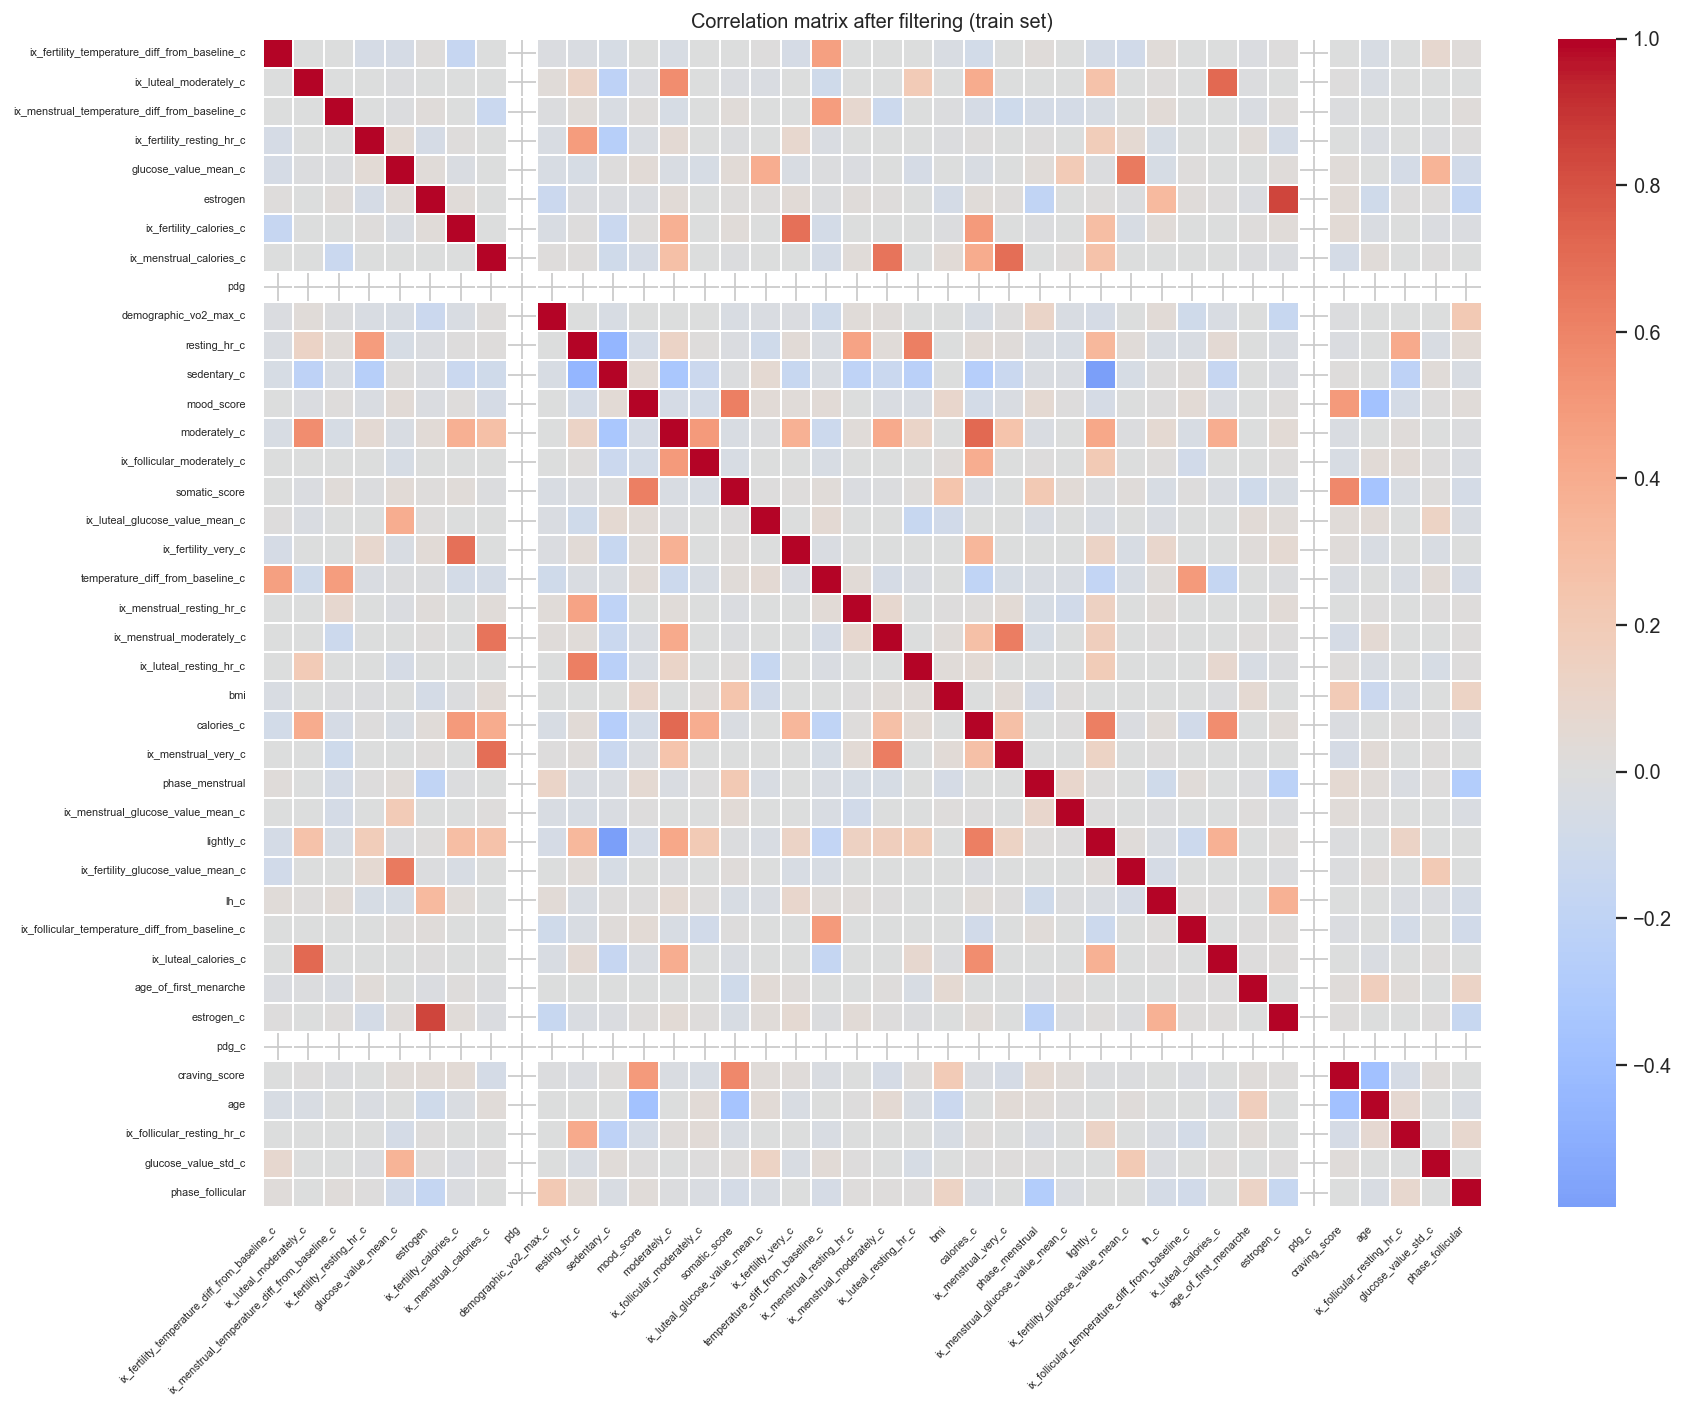

In [186]:
# Plot top remaining correlations
fig, ax = plt.subplots(figsize=(14, 11))
corr_sub = train_df[features_after_corr[:40]].corr()  # cap at 40 for readability
sns.heatmap(corr_sub, ax=ax, cmap="coolwarm", center=0,
            linewidths=0.2, annot=False)
ax.set_title("Correlation matrix after filtering (train set)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=6)
plt.yticks(fontsize=6)
savefig("3a_corr_filtered_heatmap.png")

── 3b. Lasso / ElasticNet selection ─────────────────────────────────────────
Fit a Lasso on each target using the correlation-filtered features.
Features with non-zero coefficients are selected for the main models.

In [187]:
from sklearn.linear_model import LassoCV, ElasticNetCV

In [188]:
lasso_selected = {}   # target → list of selected features

In [189]:
for target, label in TARGETS.items():
    if target not in train_df.columns:
        print(f"  [{target}] not found — skipping Lasso selection")
        continue

    # Build clean train arrays
    feat_cols = [f for f in features_after_corr if f != target]
    Xtr = train_df[feat_cols].copy()
    ytr = train_df[target].copy()

    # Drop rows where target is NaN
    mask = ytr.notna()
    Xtr, ytr = Xtr[mask], ytr[mask]

    # Impute missing features with column median (train only)
    imp = SimpleImputer(strategy="median")
    Xtr_imp = imp.fit_transform(Xtr)

    scaler   = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr_imp)

    # LassoCV (cross-validated alpha)
    lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=RANDOM_STATE)
    lasso_cv.fit(Xtr_scaled, ytr)

    selected = [feat_cols[i] for i, coef in enumerate(lasso_cv.coef_)
                if coef != 0]
    lasso_selected[target] = selected
    print(f"\n  [{label}] Lasso selected {len(selected)}/{len(feat_cols)} features "
          f"(alpha={lasso_cv.alpha_:.4f})")

    # Coefficient plot
    coef_df = pd.DataFrame({
        "feature": feat_cols,
        "coef"   : lasso_cv.coef_
    }).query("coef != 0").sort_values("coef")

    fig, ax = plt.subplots(figsize=(8, max(4, len(coef_df) * 0.3)))
    colors  = ["#e07b7b" if c > 0 else "#7bafd4" for c in coef_df["coef"]]
    ax.barh(coef_df["feature"], coef_df["coef"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Lasso coefficients — {label}", fontsize=10)
    ax.set_xlabel("Coefficient (standardised)")
    savefig(f"3b_lasso_coefs_{target}.png")


  [Fitbit Stress Score] Lasso selected 1/52 features (alpha=3.9418)


ValueError: All arrays must be of the same length

── 3c. PCA (parallel, for comparison / exploratory) ─────────────────────────
PCA is run separately — we use it to visualise structure by phase,
NOT as input to the main models (interpretability would be lost).

In [ ]:
pca_feats = [f for f in features_after_corr
             if f in train_df.columns and f not in TARGETS]

In [ ]:
Xtr_pca   = train_df[pca_feats].copy()
imp_pca   = SimpleImputer(strategy="median")
scaler_pca = StandardScaler()
Xtr_pca_s  = scaler_pca.fit_transform(imp_pca.fit_transform(Xtr_pca))

In [ ]:
pca       = PCA(n_components=0.90, random_state=RANDOM_STATE)
Xtr_pc    = pca.fit_transform(Xtr_pca_s)

In [ ]:
print(f"\n  [PCA] {pca.n_components_} components explain 90% variance")


  [PCA] 23 components explain 90% variance


Text(0.5, 1.0, 'PCA scree plot')

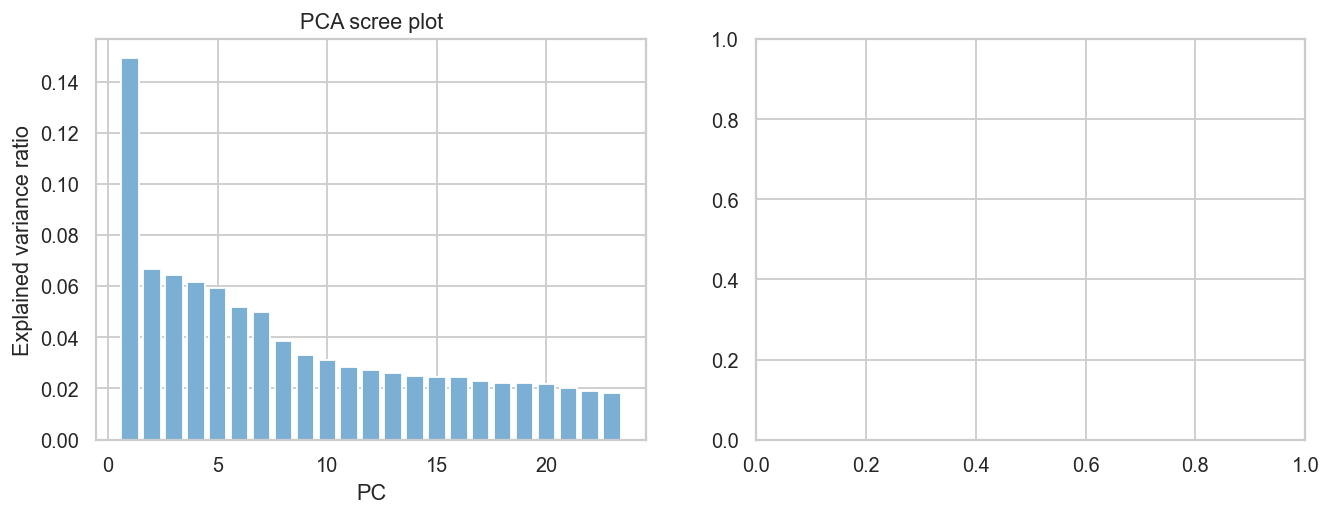

In [ ]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color="#7bafd4")
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA scree plot")

In [ ]:
axes[1].plot(np.cumsum(pca.explained_variance_ratio_), marker="o",
             color="#e07b7b")
axes[1].axhline(0.90, linestyle="--", color="grey")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title("Cumulative variance (90% threshold)")
savefig("3c_pca_scree.png")

<Figure size 832x624 with 0 Axes>

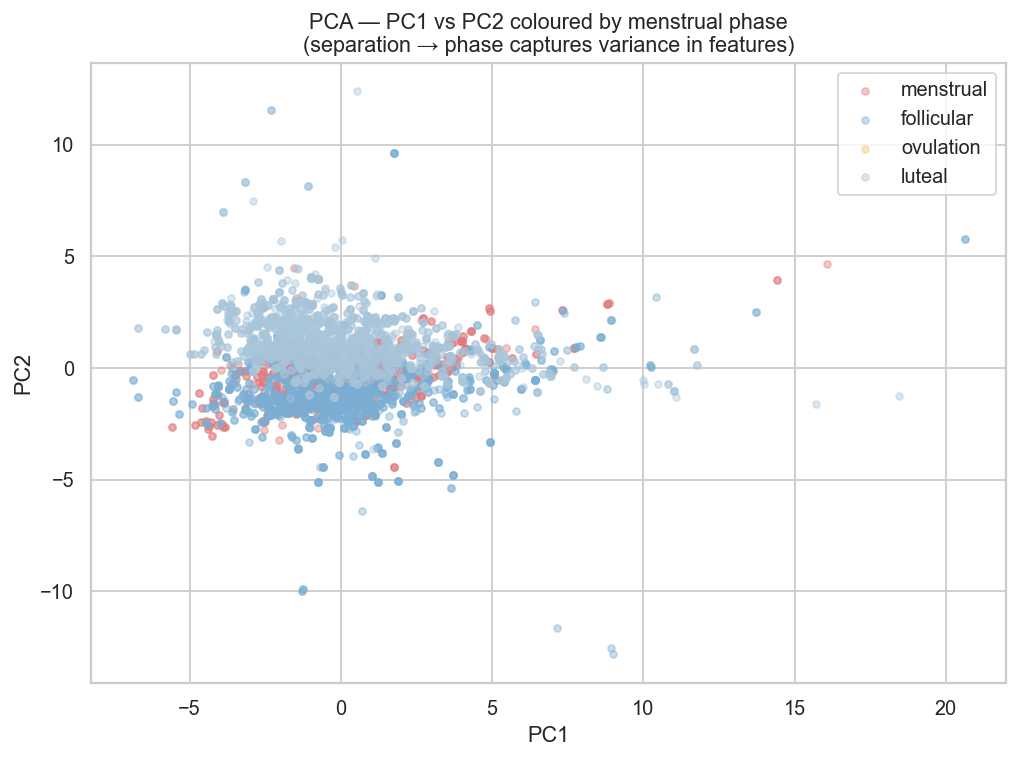

In [ ]:
# PC1 vs PC2 coloured by phase
phase_labels = train_df["phase"].values
fig, ax = plt.subplots(figsize=(8, 6))
for phase in PHASE_ORDER:
    mask = phase_labels == phase
    ax.scatter(Xtr_pc[mask, 0], Xtr_pc[mask, 1],
               color=PHASE_COLORS[phase], alpha=0.4, s=15, label=phase)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — PC1 vs PC2 coloured by menstrual phase\n"
             "(separation → phase captures variance in features)")
ax.legend()
savefig("3c_pca_phase_scatter.png")

In [ ]:
# ═════════════════════════════════════════════
# 4. MODEL TRAINING
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("4. MODEL TRAINING")
print("="*60)


4. MODEL TRAINING


── Helpers ───────────────────────────────────────────────────────────────────

In [190]:
def prepare_Xy(df, features, target):
    """Return clean X, y arrays; impute X with median, leave y as-is."""
    sub  = df[features + [target]].copy()
    mask = sub[target].notna()
    sub  = sub[mask]
    y    = sub[target].values
    X    = sub[features].values
    return X, y, sub.index

In [191]:
def build_preprocessor(X_train):
    """Fit imputer + scaler on train, return fitted objects."""
    imp = SimpleImputer(strategy="median").fit(X_train)
    sc  = StandardScaler().fit(imp.transform(X_train))
    return imp, sc

In [192]:
def apply_prep(X, imp, sc):
    return sc.transform(imp.transform(X))

In [193]:
MODELS = {
    "Ridge"   : Ridge(alpha=1.0),
    "Lasso"   : Lasso(alpha=0.01, max_iter=5000),
    "RF"      : RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                       min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1),
    "XGB"     : XGBRegressor(n_estimators=300, learning_rate=0.05,
                              max_depth=4, subsample=0.8,
                              colsample_bytree=0.8, random_state=RANDOM_STATE,
                              verbosity=0),
    "LGBM"    : LGBMRegressor(n_estimators=300, learning_rate=0.05,
                               max_depth=4, subsample=0.8,
                               colsample_bytree=0.8, random_state=RANDOM_STATE,
                               verbose=-1),
}

In [194]:
# Store results
val_results  = {}   # target → model_name → metrics dict
test_results = {}
fitted_models = {}  # target → model_name → (model, imp, sc, features)

In [ ]:
for target, label in TARGETS.items():
    print(f"\n{'─'*55}")
    print(f"TARGET: {label}  [{target}]")
    print(f"{'─'*55}")

    if target not in train_df.columns:
        print("  ⚠️  Target not in data — skipping")
        continue

    # Use Lasso-selected features for this target (fall back to corr-filtered)
    features = lasso_selected.get(target, features_after_corr)
    features = [f for f in features if f != target and f in train_df.columns]

    Xtr, ytr, _  = prepare_Xy(train_df, features, target)
    Xvl, yvl, _  = prepare_Xy(val_df,   features, target)

    imp, sc      = build_preprocessor(Xtr)
    Xtr_s        = apply_prep(Xtr, imp, sc)
    Xvl_s        = apply_prep(Xvl, imp, sc)

    val_results[target]   = {}
    fitted_models[target] = {}

    for mname, model in MODELS.items():
        try:
            model.fit(Xtr_s, ytr)
            ypred_vl = model.predict(Xvl_s)
            m = metrics(yvl, ypred_vl, label=f"{mname:<10}")
            val_results[target][mname] = m
            fitted_models[target][mname] = (model, imp, sc, features)
        except Exception as e:
            print(f"  [{mname}] FAILED: {e}")

    # ── Mixed-effects model (via statsmodels formula) ─────────────────────────
    # Uses top-5 Lasso features + phase as fixed effects,
    # random intercept per participant.
    top5_feats = features[:5]   # already ordered by |coef| from Lasso
    safe_feats = [f.replace("-", "_").replace(".", "_") for f in top5_feats]
    me_train   = train_df[["id", target, "phase"] + top5_feats].dropna().copy()
    me_val     = val_df[  ["id", target, "phase"] + top5_feats].dropna().copy()

    # Rename for formula safety
    rename_map = dict(zip(top5_feats, safe_feats))
    me_train   = me_train.rename(columns=rename_map)
    me_val     = me_val.rename(columns=rename_map)

    formula    = (f"{target} ~ phase + " +
                  " + ".join(safe_feats))
    try:
        me_model = smf.mixedlm(formula, me_train,
                                groups=me_train["id"]).fit(reml=False,
                                                            disp=False)
        ypred_me = me_model.predict(me_val)
        m_me     = metrics(me_val[target].values,
                           ypred_me.values, label="MixedLM   ")
        val_results[target]["MixedLM"] = m_me
        fitted_models[target]["MixedLM"] = (me_model, None, None, top5_feats)
    except Exception as e:
        print(f"  [MixedLM] FAILED: {e}")


───────────────────────────────────────────────────────
TARGET: Fitbit Stress Score  [stress_score]
───────────────────────────────────────────────────────


NameError: name 'lasso_selected' is not defined

In [ ]:
# ═════════════════════════════════════════════
# 5. VALIDATION MODEL COMPARISON
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("5. VALIDATION — MODEL COMPARISON")
print("="*60)


5. VALIDATION — MODEL COMPARISON


In [ ]:
best_models = {}   # target → best model name

In [ ]:
for target, label in TARGETS.items():
    if target not in val_results:
        continue

    results_df = (pd.DataFrame(val_results[target]).T
                    .sort_values("R2", ascending=False))
    print(f"\n[{label}]")
    print(results_df.to_string())

    best_name = results_df["R2"].idxmax()
    best_models[target] = best_name
    print(f"  → Best model: {best_name}")

    # Bar chart: R² per model on validation set
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
        vals   = results_df[metric]
        colors = ["#5b8db8" if m != best_name else "#e07b7b"
                  for m in vals.index]
        ax.bar(vals.index, vals.values, color=colors)
        ax.set_title(metric)
        ax.set_xlabel("Model")
        plt.xticks(rotation=30, ha="right")
    plt.suptitle(f"Validation metrics — {label}", fontsize=11)
    savefig(f"5_val_comparison_{target}.png")

In [ ]:
# ═════════════════════════════════════════════
# 6. TEST SET EVALUATION (best model per target)
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("6. TEST SET EVALUATION")
print("="*60)


6. TEST SET EVALUATION


In [ ]:
test_results = {}

In [195]:
for target, label in TARGETS.items():
    if target not in best_models:
        continue

    best_name           = best_models[target]
    model, imp, sc, features = fitted_models[target][best_name]

    if best_name == "MixedLM":
        # Mixed effects: use formula prediction
        top5_feats = features[:5]
        safe_feats = [f.replace("-", "_").replace(".", "_") for f in top5_feats]
        me_test    = test_df[["id", target, "phase"] + top5_feats].dropna().copy()
        rename_map = dict(zip(top5_feats, safe_feats))
        me_test    = me_test.rename(columns=rename_map)
        ypred      = model.predict(me_test)
        ytrue      = me_test[target].values
    else:
        Xte, yte, idx = prepare_Xy(test_df, features, target)
        Xte_s         = apply_prep(Xte, imp, sc)
        ypred         = model.predict(Xte_s)
        ytrue         = yte

    m = metrics(ytrue, ypred, label=f"{best_name} → {label}")
    test_results[target] = {"model": best_name, **m}

    # Actual vs predicted scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(ytrue, ypred, alpha=0.4, s=15, color="#7bafd4")
    mn = min(ytrue.min(), ypred.min())
    mx = max(ytrue.max(), ypred.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.2, label="Perfect")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{label} — {best_name}\nTest: "
                 f"MAE={m['MAE']:.2f}  R²={m['R2']:.3f}")
    ax.legend()
    savefig(f"6_test_actual_vs_pred_{target}.png")

NameError: name 'best_models' is not defined

In [ ]:
# ═════════════════════════════════════════════
# 7. SHAP FEATURE IMPORTANCE
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("7. SHAP FEATURE IMPORTANCE")
print("="*60)


7. SHAP FEATURE IMPORTANCE


In [ ]:
for target, label in TARGETS.items():
    best_name = best_models.get(target)
    if best_name not in ("RF", "XGB", "LGBM"):
        # SHAP TreeExplainer only works for tree models
        # Fall back to permutation importance for Ridge/Lasso/MixedLM
        print(f"  [{label}] best={best_name} → using permutation importance")
        if best_name in ("Ridge", "Lasso") and target in fitted_models:
            model, imp, sc, features = fitted_models[target][best_name]
            Xte, yte, _ = prepare_Xy(test_df, features, target)
            Xte_s = apply_prep(Xte, imp, sc)
            pi = permutation_importance(model, Xte_s, yte,
                                         n_repeats=20,
                                         random_state=RANDOM_STATE)
            imp_df = (pd.DataFrame({"feature": features,
                                    "importance": pi.importances_mean})
                        .sort_values("importance", ascending=False)
                        .head(20))
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.barh(imp_df["feature"][::-1],
                    imp_df["importance"][::-1], color="#a8c5da")
            ax.set_title(f"Permutation importance — {label} ({best_name})")
            ax.set_xlabel("Mean importance")
            savefig(f"7_permutation_imp_{target}.png")
        continue

    model, imp, sc, features = fitted_models[target][best_name]
    Xte, yte, _ = prepare_Xy(test_df, features, target)
    Xte_s = apply_prep(Xte, imp, sc)

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(Xte_s)

    # Summary beeswarm
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, Xte_s,
                      feature_names=features,
                      plot_type="dot",
                      show=False, max_display=20)
    plt.title(f"SHAP beeswarm — {label} ({best_name})")
    savefig(f"7_shap_beeswarm_{target}.png")

    # Bar summary
    fig, ax = plt.subplots(figsize=(9, 5))
    shap.summary_plot(shap_values, Xte_s,
                      feature_names=features,
                      plot_type="bar",
                      show=False, max_display=20)
    plt.title(f"SHAP mean |value| — {label} ({best_name})")
    savefig(f"7_shap_bar_{target}.png")

  [Fitbit Stress Score] best=None → using permutation importance
  [HRV (RMSSD)] best=None → using permutation importance
  [Sleep Score] best=None → using permutation importance


In [ ]:
# ═════════════════════════════════════════════
# 8. PHASE-STRATIFIED PERFORMANCE
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("8. PHASE-STRATIFIED PERFORMANCE")
print("="*60)
# This directly tests the hypothesis:
# does model performance differ by phase?
# Poor performance in a specific phase → model doesn't capture
# that phase's baseline shift well → indicates need for phase-specific tuning.


8. PHASE-STRATIFIED PERFORMANCE


In [ ]:
phase_perf_all = {}

In [ ]:
for target, label in TARGETS.items():
    best_name = best_models.get(target)
    if best_name is None or best_name == "MixedLM":
        continue

    model, imp, sc, features = fitted_models[target][best_name]

    phase_perf = {}
    for phase in PHASE_ORDER:
        phase_test = test_df[test_df["phase"] == phase].copy()
        if len(phase_test) < 5:
            continue
        Xph, yph, _ = prepare_Xy(phase_test, features, target)
        if len(Xph) == 0:
            continue
        Xph_s = apply_prep(Xph, imp, sc)
        yph_pred = model.predict(Xph_s)
        m = metrics(yph, yph_pred)
        phase_perf[phase] = m
        print(f"  [{label}] phase={phase:<12} "
              f"MAE={m['MAE']:.3f}  R²={m['R2']:.3f}  n={len(yph)}")

    phase_perf_all[target] = phase_perf

    # Plot R² and MAE by phase
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    phases_found = list(phase_perf.keys())
    r2s  = [phase_perf[p]["R2"]  for p in phases_found]
    maes = [phase_perf[p]["MAE"] for p in phases_found]

    axes[0].bar(phases_found, r2s,
                color=[PHASE_COLORS.get(p, "#aaa") for p in phases_found])
    axes[0].set_title(f"R² by phase — {label}")
    axes[0].set_ylabel("R²")
    axes[0].axhline(test_results.get(target, {}).get("R2", 0),
                    linestyle="--", color="black", linewidth=0.8,
                    label="Overall R²")
    axes[0].legend(fontsize=8)

    axes[1].bar(phases_found, maes,
                color=[PHASE_COLORS.get(p, "#aaa") for p in phases_found])
    axes[1].set_title(f"MAE by phase — {label}")
    axes[1].set_ylabel("MAE")
    axes[1].axhline(test_results.get(target, {}).get("MAE", 0),
                    linestyle="--", color="black", linewidth=0.8,
                    label="Overall MAE")
    axes[1].legend(fontsize=8)

    plt.suptitle(
        f"Phase-stratified test performance — {label}\n"
        "Gap from dashed line = phase where model struggles most",
        fontsize=10)
    savefig(f"8_phase_perf_{target}.png")

In [ ]:
# ═════════════════════════════════════════════
# 9. SUMMARY REPORT
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("9. SUMMARY REPORT")
print("="*60)


9. SUMMARY REPORT


In [ ]:
report_lines = [
    "mcPHASES MODELING SUMMARY",
    "=" * 50,
    f"Train participants : {len(train_ids)}",
    f"Val   participants : {len(val_ids)}",
    f"Test  participants : {len(test_ids)}",
    f"Feature pool (post corr-filter): {len(features_after_corr)}",
    "",
    "BEST MODELS (by validation R²):",
]
for target, label in TARGETS.items():
    if target not in test_results:
        continue
    tr = test_results[target]
    report_lines.append(
        f"  {label:<25} | best={tr['model']:<10} | "
        f"test MAE={tr['MAE']:.3f}  RMSE={tr['RMSE']:.3f}  R²={tr['R2']:.3f}"
    )

In [ ]:
report_lines += [
    "",
    "PHASE-STRATIFIED R² (test set):",
]
for target, label in TARGETS.items():
    if target not in phase_perf_all:
        continue
    report_lines.append(f"  {label}:")
    for phase, m in phase_perf_all[target].items():
        report_lines.append(f"    {phase:<14} R²={m['R2']:.3f}  MAE={m['MAE']:.3f}")

In [ ]:
report_lines += [
    "",
    "INTERPRETATION NOTES:",
    "  - Phases where R² drops sharply suggest the model fails to capture",
    "    that phase's unique physiological baseline — prime candidates for",
    "    phase-specific sub-models or additional phase interaction terms.",
    "  - SHAP plots reveal which features drive predictions; if interaction",
    "    terms (ix_*) rank highly, the phase-shift hypothesis is supported.",
    "  - MixedLM random intercepts absorb between-person variance; compare",
    "    its performance to RF/XGB to quantify how much variance is person-",
    "    level vs feature-driven.",
    "",
    "NEXT STEPS:",
    "  1. Retrain best model per target on train+val combined.",
    "  2. Evaluate on Interval 2 data (out-of-distribution / longitudinal).",
    "  3. For phases with poor R²: train phase-specific sub-models.",
    "  4. Translate phase-relative feature weights into exercise advisories.",
]

In [ ]:
report_text = "\n".join(report_lines)
print(report_text)

mcPHASES MODELING SUMMARY
Train participants : 30
Val   participants : 6
Test  participants : 6
Feature pool (post corr-filter): 52

BEST MODELS (by validation R²):

PHASE-STRATIFIED R² (test set):

INTERPRETATION NOTES:
  - Phases where R² drops sharply suggest the model fails to capture
    that phase's unique physiological baseline — prime candidates for
    phase-specific sub-models or additional phase interaction terms.
  - SHAP plots reveal which features drive predictions; if interaction
    terms (ix_*) rank highly, the phase-shift hypothesis is supported.
  - MixedLM random intercepts absorb between-person variance; compare
    its performance to RF/XGB to quantify how much variance is person-
    level vs feature-driven.

NEXT STEPS:
  1. Retrain best model per target on train+val combined.
  2. Evaluate on Interval 2 data (out-of-distribution / longitudinal).
  3. For phases with poor R²: train phase-specific sub-models.
  4. Translate phase-relative feature weights into exe

In [ ]:
report_path = os.path.join(OUT_DIR, "summary_report.txt")
with open(report_path, "w") as f:
    f.write(report_text)

In [ ]:
# Also save test results as JSON for downstream use
json_path = os.path.join(OUT_DIR, "test_results.json")
with open(json_path, "w") as f:
    json.dump(test_results, f, indent=2)

In [ ]:
print(f"\n✓ Script 3 complete.")
print(f"  Report : {os.path.abspath(report_path)}")
print(f"  Figures: {os.path.abspath(OUT_DIR)}")


✓ Script 3 complete.
  Report : /Users/kikkiliu/physionet.org/files/mcphases/eda_outputs/script3_modeling/summary_report.txt
  Figures: /Users/kikkiliu/physionet.org/files/mcphases/eda_outputs/script3_modeling


In [202]:
[c for c in train_df.columns if any(k in c.lower() for k in ["rmssd", "hrv", "low_frequency", "high_frequency"])]

['rmssd', 'low_frequency', 'high_frequency']

In [203]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================================================
# 0. TARGET + PHASE DETECTION
# =========================================================
def infer_hrv_target(df):
    candidates = ["rmssd_mean", "rmssd"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        "No HRV target found. rmssd-like columns available: "
        + str([x for x in df.columns if "rmssd" in x.lower()])
    )

TARGET = infer_hrv_target(train_df)

if "phase" not in train_df.columns:
    raise ValueError("'phase' column not found in train_df")
if "phase" not in test_df.columns:
    raise ValueError("'phase' column not found in test_df")

PHASE_ORDER = sorted(train_df["phase"].dropna().astype(str).unique().tolist())

print("Using TARGET:", TARGET)
print("Observed train phases:", PHASE_ORDER)
print("Observed test phases :", sorted(test_df["phase"].dropna().astype(str).unique().tolist()))


# =========================================================
# 1. FEATURE HELPERS
# =========================================================
def get_feature_list(df, target):
    centered_feats = [c for c in df.columns if c.endswith("_c")]
    static_feats = [c for c in ["age", "bmi", "age_of_first_menarche"] if c in df.columns]
    hormone_feats = [c for c in ["lh", "estrogen", "pdg"] if c in df.columns]
    composite_feats = [c for c in ["somatic_score", "mood_score", "craving_score"] if c in df.columns]
    extra_feats = [c for c in [
        "low_frequency_mean", "high_frequency_mean",
        "resting_hr", "full_sleep_breathing_rate"
    ] if c in df.columns]

    feats = list(dict.fromkeys(
        centered_feats + static_feats + hormone_feats + composite_feats + extra_feats
    ))
    feats = [f for f in feats if f != target]
    return feats


def get_feature_list_with_phase(df, target):
    feats = get_feature_list(df, target)

    # use existing one-hot phase columns if they are already in your dataframe
    phase_dummies = [c for c in df.columns if c.startswith("phase_")]
    feats = list(dict.fromkeys(feats + phase_dummies))
    feats = [f for f in feats if f != target]
    return feats


# =========================================================
# 2. METRICS
# =========================================================
def regression_metrics(y_true, y_pred):
    mask = ~(pd.isna(y_true) | pd.isna(y_pred))
    y_true = np.asarray(y_true)[mask]
    y_pred = np.asarray(y_pred)[mask]

    if len(y_true) < 3:
        return {"R2": np.nan, "MAE": np.nan, "n": len(y_true)}

    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "n": len(y_true)
    }


# =========================================================
# 3. PREPROCESSING
# =========================================================
def fit_preprocessor(X):
    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()
    X_imp = imp.fit_transform(X)
    X_sc = sc.fit_transform(X_imp)
    return imp, sc


def transform_X(X, imp, sc):
    return sc.transform(imp.transform(X))


# =========================================================
# 4. MODEL FITTING
# =========================================================
def fit_global_model(train_df, feature_cols, target):
    required_cols = [c for c in feature_cols + [target] if c in train_df.columns]
    sub = train_df[required_cols].dropna(subset=[target]).copy()

    print(f"\n[GLOBAL] train rows used: {len(sub)}")
    print(f"[GLOBAL] features used   : {len(feature_cols)}")

    X = sub[feature_cols]
    y = sub[target].values

    imp, sc = fit_preprocessor(X)
    Xp = transform_X(X, imp, sc)

    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xp, y)

    return {"model": model, "imp": imp, "sc": sc, "features": feature_cols}


def fit_phase_models(train_df, feature_cols, target, phase_order):
    phase_models = {}

    for phase in phase_order:
        sub = train_df[train_df["phase"].astype(str) == str(phase)].copy()
        sub = sub[feature_cols + [target]].dropna(subset=[target]).copy()

        print(f"[PHASE={phase}] usable train rows: {len(sub)}")

        if len(sub) < 20:
            print(f"  -> too few rows, fallback will be used on test")
            phase_models[phase] = None
            continue

        X = sub[feature_cols]
        y = sub[target].values

        imp, sc = fit_preprocessor(X)
        Xp = transform_X(X, imp, sc)

        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
        model.fit(Xp, y)

        phase_models[phase] = {
            "model": model,
            "imp": imp,
            "sc": sc,
            "features": feature_cols
        }

    return phase_models


# =========================================================
# 5. PREDICTION HELPERS
# =========================================================
def predict_global(bundle, df, target):
    out = df.copy().reset_index().rename(columns={"index": "row_id"})
    valid = out[["row_id", "phase"] + bundle["features"] + [target]].dropna(subset=[target]).copy()

    Xp = transform_X(valid[bundle["features"]], bundle["imp"], bundle["sc"])
    valid["pred_global"] = bundle["model"].predict(Xp)

    return valid[["row_id", "phase", target, "pred_global"]]


def predict_phasewise(phase_bundles, df, target, phase_order, fallback_mean):
    out = df.copy().reset_index().rename(columns={"index": "row_id"})
    preds = []

    for phase in phase_order:
        sub = out[out["phase"].astype(str) == str(phase)].copy()
        sub = sub.dropna(subset=[target]).copy()

        if sub.empty:
            print(f"[PHASE={phase}] no test rows")
            continue

        bundle = phase_bundles.get(phase)

        if bundle is None:
            print(f"[PHASE={phase}] using fallback mean on {len(sub)} test rows")
            sub["pred_phasewise"] = fallback_mean
        else:
            print(f"[PHASE={phase}] using trained phase model on {len(sub)} test rows")
            Xp = transform_X(sub[bundle["features"]], bundle["imp"], bundle["sc"])
            sub["pred_phasewise"] = bundle["model"].predict(Xp)

        preds.append(sub[["row_id", "phase", target, "pred_phasewise"]])

    if preds:
        return pd.concat(preds, axis=0, ignore_index=True)

    return pd.DataFrame(columns=["row_id", "phase", target, "pred_phasewise"])


# =========================================================
# 6. MAIN EVALUATION: GLOBAL VS 4 PHASE MODELS
# =========================================================
def evaluate_global_vs_phase(train_df, test_df, target):
    feature_cols = get_feature_list(train_df, target)

    print(f"\nNumber of base features: {len(feature_cols)}")
    print("First 20 base features:", feature_cols[:20])

    global_bundle = fit_global_model(train_df, feature_cols, target)
    phase_bundles = fit_phase_models(train_df, feature_cols, target, PHASE_ORDER)

    fallback_mean = train_df[target].dropna().mean()
    print("\nFallback mean:", fallback_mean)

    gpred = predict_global(global_bundle, test_df, target)
    ppred = predict_phasewise(phase_bundles, test_df, target, PHASE_ORDER, fallback_mean)

    merged = gpred.merge(
        ppred[["row_id", "pred_phasewise"]],
        on="row_id",
        how="inner"
    )

    print("\nMerged rows:", len(merged))
    print(merged.head())

    overall_global = regression_metrics(merged[target], merged["pred_global"])
    overall_phase = regression_metrics(merged[target], merged["pred_phasewise"])

    print("\n=== OVERALL HRV COMPARISON ===")
    print(f"Global model   : R²={overall_global['R2']:.3f}, MAE={overall_global['MAE']:.3f}, n={overall_global['n']}")
    print(f"Phasewise model: R²={overall_phase['R2']:.3f}, MAE={overall_phase['MAE']:.3f}, n={overall_phase['n']}")

    if pd.notna(overall_phase["R2"]) and pd.notna(overall_global["R2"]):
        if overall_phase["R2"] > overall_global["R2"]:
            print("Winner by overall R²: 4 phase models")
        else:
            print("Winner by overall R²: 1 global model")

    rows = []
    for phase in PHASE_ORDER:
        sub = merged[merged["phase"].astype(str) == str(phase)]
        if len(sub) == 0:
            continue

        mg = regression_metrics(sub[target], sub["pred_global"])
        mp = regression_metrics(sub[target], sub["pred_phasewise"])

        rows.append({
            "phase": phase,
            "global_R2": mg["R2"],
            "global_MAE": mg["MAE"],
            "phasewise_R2": mp["R2"],
            "phasewise_MAE": mp["MAE"],
            "n": mg["n"]
        })

    phase_report = pd.DataFrame(rows)

    print("\n=== PER-PHASE HRV COMPARISON ===")
    if len(phase_report) > 0:
        print(phase_report.to_string(index=False))
    else:
        print("No per-phase rows available.")

    return {
        "global_bundle": global_bundle,
        "phase_bundles": phase_bundles,
        "predictions": merged,
        "phase_report": phase_report,
        "overall_global": overall_global,
        "overall_phase": overall_phase
    }


# =========================================================
# 7. OPTIONAL: GLOBAL MODEL + EXPLICIT PHASE FEATURES
# =========================================================
def ensure_phase_dummies(train_df, test_df, phase_order):
    train_out = train_df.copy()
    test_out = test_df.copy()

    for phase in phase_order:
        col = f"phase_{phase}"
        train_out[col] = (train_out["phase"].astype(str) == str(phase)).astype(int)
        test_out[col] = (test_out["phase"].astype(str) == str(phase)).astype(int)

    return train_out, test_out


def evaluate_global_with_phase(train_df, test_df, target):
    train2, test2 = ensure_phase_dummies(train_df, test_df, PHASE_ORDER)
    feature_cols = get_feature_list_with_phase(train2, target)

    print(f"\nNumber of features (with phase dummies): {len(feature_cols)}")
    print("First 20 features:", feature_cols[:20])

    bundle = fit_global_model(train2, feature_cols, target)
    preds = predict_global(bundle, test2, target).rename(columns={"pred_global": "pred_global_with_phase"})

    metrics = regression_metrics(preds[target], preds["pred_global_with_phase"])

    print("\n=== GLOBAL + PHASE FEATURES ===")
    print(f"Global+Phase model: R²={metrics['R2']:.3f}, MAE={metrics['MAE']:.3f}, n={metrics['n']}")

    return {
        "bundle": bundle,
        "predictions": preds,
        "metrics": metrics
    }


# =========================================================
# 8. RUN EVERYTHING
# =========================================================
print("\n=== Train rows with HRV target per phase ===")
print(train_df.dropna(subset=[TARGET]).groupby("phase").size())

print("\n=== Test rows with HRV target per phase ===")
print(test_df.dropna(subset=[TARGET]).groupby("phase").size())

print("\n=== HRV target distribution by phase (train) ===")
print(
    train_df.dropna(subset=[TARGET])
    .groupby("phase")[TARGET]
    .agg(["count", "mean", "std", "min", "max"])
)

hrv_compare = evaluate_global_vs_phase(train_df, test_df, TARGET)
hrv_global_phase = evaluate_global_with_phase(train_df, test_df, TARGET)


# =========================================================
# 9. DIRECT 3-WAY COMPARISON
# =========================================================
base = hrv_compare["predictions"].merge(
    hrv_global_phase["predictions"][["row_id", "pred_global_with_phase"]],
    on="row_id",
    how="left"
)

print("\n=== 3-WAY COMPARISON ===")
print("Global only    :", regression_metrics(base[TARGET], base["pred_global"]))
print("Global + phase :", regression_metrics(base[TARGET], base["pred_global_with_phase"]))
print("4 phase models :", regression_metrics(base[TARGET], base["pred_phasewise"]))

print("\n=== Phase model availability ===")
for phase, bundle in hrv_compare["phase_bundles"].items():
    print(phase, "->", "trained" if bundle is not None else "fallback")

base["diff_phasewise_minus_global"] = base["pred_phasewise"] - base["pred_global"]
print("\n=== Prediction difference summary ===")
print(base["diff_phasewise_minus_global"].describe())

print("\n=== Correlation among predictions ===")
print(base[["pred_global", "pred_global_with_phase", "pred_phasewise"]].corr())

Using TARGET: rmssd
Observed train phases: ['fertility', 'follicular', 'luteal', 'menstrual']
Observed test phases : ['fertility', 'follicular', 'luteal', 'menstrual']

=== Train rows with HRV target per phase ===
phase
fertility     1230
follicular    1317
luteal        1866
menstrual      987
dtype: int64

=== Test rows with HRV target per phase ===
phase
fertility     261
follicular    347
luteal        334
menstrual     203
dtype: int64

=== HRV target distribution by phase (train) ===
            count       mean        std        min         max
phase                                                         
fertility    1230  48.772584  24.137036  11.676035  163.644700
follicular   1317  53.672194  24.806121  13.773179  147.398250
luteal       1866  51.000753  29.969446   9.482782  175.528705
menstrual     987  53.241917  29.295906   0.000000  183.877011

Number of base features: 52
First 20 base features: ['resting_hr_c', 'calories_c', 'steps_c', 'distance_c', 'sedentary_c', 'li